In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

REPO = Path('..').resolve()
DATASET_DIR = (REPO / 'results' /
    'phase_shear')

def load_runs(prefix):
    runs = []
    for pkl in sorted(DATASET_DIR.glob(f'{prefix}_run_*.pkl')):
        with open(pkl, 'rb') as f:
            runs.append(pickle.load(f))
    return runs

moment_runs = load_runs('phase_shear')
prior_runs  = load_runs('map_prior')
print(f'Loaded {len(moment_runs)} map_moment runs, {len(prior_runs)} map_prior runs')

As_true = moment_runs[0]['As_true']
Ac_true = moment_runs[0]['Ac_true']
print(f'As_true={As_true:.4f}  Ac_true={Ac_true:.4f}')


Loaded 13 map_moment runs, 0 map_prior runs
As_true=0.0878  Ac_true=0.0479


In [37]:
phi0_z0 = []
phi0_z100= []
run_idx = 1
for i in range(200):
    phi0_z0.append(moment_runs[run_idx]['rows'][i]['fit_z0']['phi_0'])
    phi0_z100.append(moment_runs[run_idx]['rows'][i]['fit_z100']['phi_0'])

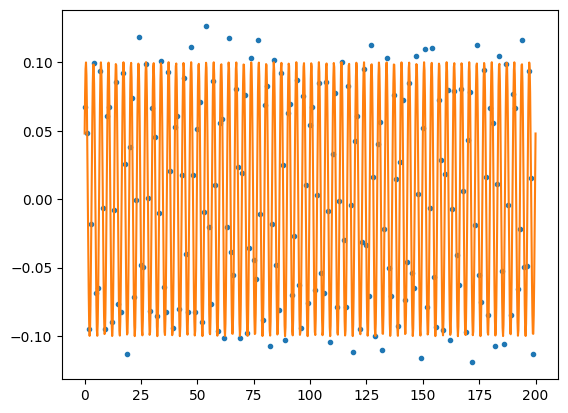

In [38]:
signal_hat = np.unwrap(np.array(phi0_z0) - np.array(phi0_z100))
signal_hat -= np.mean(signal_hat)
plt.plot(signal_hat,'.')
idx = np.linspace(0,200,1000)
signal = As_true * np.sin(2*np.pi*0.3*idx) + Ac_true * np.cos(2*np.pi*0.3*idx)
plt.plot(idx,signal)

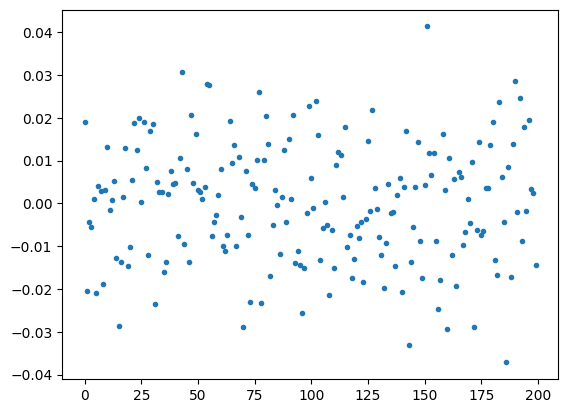

In [39]:
idx = np.arange(200)
res = signal_hat - (As_true * np.sin(2*np.pi*0.3*idx) + Ac_true * np.cos(2*np.pi*0.3*idx))
plt.figure()
plt.plot(res,'.')

In [ ]:
# see if dependence of phi0 on the final moments, kappa and gamma 
from 